# Notebook 03 — Feature Engineering

**Philippine Weekly Diesel Price Forecasting**

### References

- Lunor, S.B.R. et al. (2023). Machine Learning Approach for Pump Price Prediction for the Philippines Post COVID-19. *Chemical Engineering Transactions*, 103, 265–270.
- Wen, D. et al. (2025). Forecasting gasoline prices: New evidence based on the rocket and feather hypothesis. *Energy*, 335.
- Borenstein, S., Cameron, A.C., & Gilbert, R. (1997). Do Gasoline Prices Respond Asymmetrically to Crude Oil Price Changes? *Quarterly Journal of Economics*, 112(1), 305–339.
- Caldara, D. & Iacoviello, M. (2022). Measuring Geopolitical Risk. *American Economic Review*, 112(4), 1194–1225.
- Hamilton, J.D. (1989). A New Approach to the Economic Analysis of Nonstationary Time Series. *Econometrica*, 57(2), 357–384.

### EDA decisions implemented in this notebook

| # | EDA Finding | Engineering Decision |
|---|---|---|
| 1 | Diesel price is I(1) — non-stationary in levels (ADF p > 0.05) | Model on **log returns** Δlog(diesel), not levels |
| 2 | Lag-0 same-week Brent/FX — temporal data leakage | All market features lagged ≥ 1 week before the DOE Tuesday bulletin |
| 3 | CCF MOPS→diesel peaks at lag 1, decays by lag 4 | Lags 1–4 on upstream drivers |
| 4 | Own-price autocorrelation ≈ 0.97 | Own log-return lags 1–4 unconditionally included |
| 5 | RFH asymmetry confirmed in diesel | Split Brent Δlog into positive / negative components (Wen et al., 2025) |
| 6 | Markov variance ratio ≈ 32× — two clear volatility regimes | `markov_prob_highvol` as a continuous regime covariate |
| 7 | Crisis shocks outside normal regime | Binary dummies: COVID-19, Russia–Ukraine, OPEC+/Iran 2026 |
| 8 | MOPS flagged as leakage | Replaced by `crack_spread` = mops_gasoil − brent (refining margin, correct sign) |
| 9 | Excise tax embedded in observed pump price | Excise level excluded; a step-change impulse at each TRAIN Law tranche is retained |
| 10 | Brent–Dubai–MOPS highly collinear in levels | PCA on the lagged log-return block to compress collinearity |

### On the modeling target

The ADF test confirmed all price series are **I(1)**. Modelling price levels is therefore spurious — the
model learns the trend, not the signal, and degenerates to the AR(1) copy: $\hat p_t \approx p_{t-1}$
(the professor's critique). The correct transformation is the **log return**:

$$r_t = \Delta\log p_t = \log\left(\frac{p_t}{p_{t-1}}\right)$$

which is stationary by construction. At prediction time the level is recovered via

$$\hat{p}_t = p_{t-1} \cdot \exp(\hat{r}_t)$$

This notebook engineers all features for the **diesel** product only. The same pipeline extends to
`ron91`, `ron95`, `ron97` with the appropriate own-price lags substituted.


---
## Section 1 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as transforms
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import t as t_dist

# Import professor's utility functions
import sys
sys.path.insert(0, '.')
from utils import plot_cum_exp_var, plot_principal_components

os.makedirs('data/final', exist_ok=True)

# ── Plotting style — clean, no grid, matches professor's notebook ──────────
plt.rcParams.update({
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          False,
    'figure.dpi':         100,
})

# ── Crisis shade bands (for time-series plots) ─────────────────────────────
CRISIS_BANDS = [
    ('2020-03-09', '2020-06-15', '#4e79a7', 'COVID-19'),
    ('2022-02-24', '2022-12-31', '#e15759', 'Russia–Ukraine'),
    ('2026-01-01', '2026-04-30', '#f28e2b', 'OPEC+/Iran 2026'),
]

def shade_crises(ax, alpha=0.12):
    """Shade crisis periods on a time-series axis."""
    for start, end, color, label in CRISIS_BANDS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   color=color, alpha=alpha, label=label)

def fmt_xaxis(ax):
    """Format x-axis as 4-digit year labels."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

# ── Constants ─────────────────────────────────────────────────────────────
TARGET_PRODUCT = 'diesel'
LAGS           = [1, 2, 3, 4]


---
## Section 2 — Load Master Frame

We load from `master_pre_engineered.parquet`, the output of Notebook 02. This frame contains all
raw weekly series aligned on the DOE Tuesday bulletin index, along with regime flags computed in
the EDA (Markov state probability, crisis dummies, structural break labels).


In [2]:
df = pd.read_parquet('data/final/master_pre_engineered.parquet')

print(f'Shape  : {df.shape}')
print(f'Dates  : {df.index.min().date()}  →  {df.index.max().date()}')
print(f'Index  : {df.index.name}  ({df.index.dtype})')
print()
print('Columns:')
for c in df.columns:
    print(f'  {c}')


Shape  : (373, 34)
Dates  : 2018-02-13  →  2026-04-28
Index  : None  (datetime64[ns])

Columns:
  usd_php_mean
  brent_mean
  mops_gasoil_mean
  mops_rbob_mean
  dubai_close
  cpi_value
  rub_usd_mean
  vix_mean
  GPR_AI
  GPR_OIL
  GPR_OIL_MiddleEast
  GPR_OIL_Russia
  GPR_NONOIL
  ovx_mean
  diesel
  diesel_plus
  kerosene
  ron100
  ron91
  ron95
  ron97
  diesel_chg
  markov_prob_highvol
  markov_regime_flag
  d_covid
  d_ukraine
  d_iran26
  anomaly_flag
  crisis_intensity
  iso_score
  iso_flag
  pelt_regime
  ovx_z
  gpr_z


### 2.1 Diesel null handling

The DOE occasionally skips a bulletin week (holiday, data delay). Forward-fill is the only
safe strategy: it carries the last observed price forward, which is what a market participant
would also assume. **Back-fill is never used** — it would propagate a future price into a past
row, introducing look-ahead bias.


In [3]:
# Forward-fill diesel only — no bfill
df[TARGET_PRODUCT] = df[TARGET_PRODUCT].ffill()

n_remaining_null = df[TARGET_PRODUCT].isna().sum()
print(f'Null diesel prices after ffill : {n_remaining_null}')
if n_remaining_null > 0:
    print('  → Dropping leading rows with no prior observation.')
    df = df.dropna(subset=[TARGET_PRODUCT])

print(f'Working rows : {len(df)}')
print(f'Date range   : {df.index.min().date()}  →  {df.index.max().date()}')


Null diesel prices after ffill : 0
Working rows : 373
Date range   : 2018-02-13  →  2026-04-28


---
## Section 3 — Modeling Target: Diesel Log Return

The modeling target is the week-on-week log return of the diesel pump price:

$$r_t = \log\left(\frac{p_t}{p_{t-1}}\right)$$

This is the **first log-difference** of the level series. The EDA (Section 4) confirmed via
Augmented Dickey–Fuller that the level series is I(1) and the first-differenced series is
stationary (ADF p < 0.01). Log returns are preferred over raw differences because they are
symmetric, approximately normally distributed, and admit a clean back-transformation to price
levels without compounding errors.

**All models in Notebook 04 predict `diesel_log_ret`. Level predictions are recovered as
$\hat{p}_t = p_{t-1} \cdot \exp(\hat{r}_t)$ before computing MAPE.**


In [4]:
# ── Construct log return ───────────────────────────────────────────────────
df['diesel_log_ret'] = np.log(df[TARGET_PRODUCT] / df[TARGET_PRODUCT].shift(1))

# Descriptive check
desc = df['diesel_log_ret'].describe()
print('Diesel log return — descriptive statistics')
print('-' * 44)
print(desc.round(6).to_string())
print()
print('Interpretation:')
print(f'  Mean  ≈ 0 (weekly average change near zero) : {df["diesel_log_ret"].mean():.5f}')
print(f'  Std   ≈ 0.01–0.05 for administered prices   : {df["diesel_log_ret"].std():.5f}')
print(f'  Range : [{df["diesel_log_ret"].min():.4f},  {df["diesel_log_ret"].max():.4f}]')


Diesel log return — descriptive statistics
--------------------------------------------
count    372.000000
mean       0.002091
std        0.042640
min       -0.224966
25%       -0.014623
50%        0.000476
75%        0.017033
max        0.334706

Interpretation:
  Mean  ≈ 0 (weekly average change near zero) : 0.00209
  Std   ≈ 0.01–0.05 for administered prices   : 0.04264
  Range : [-0.2250,  0.3347]


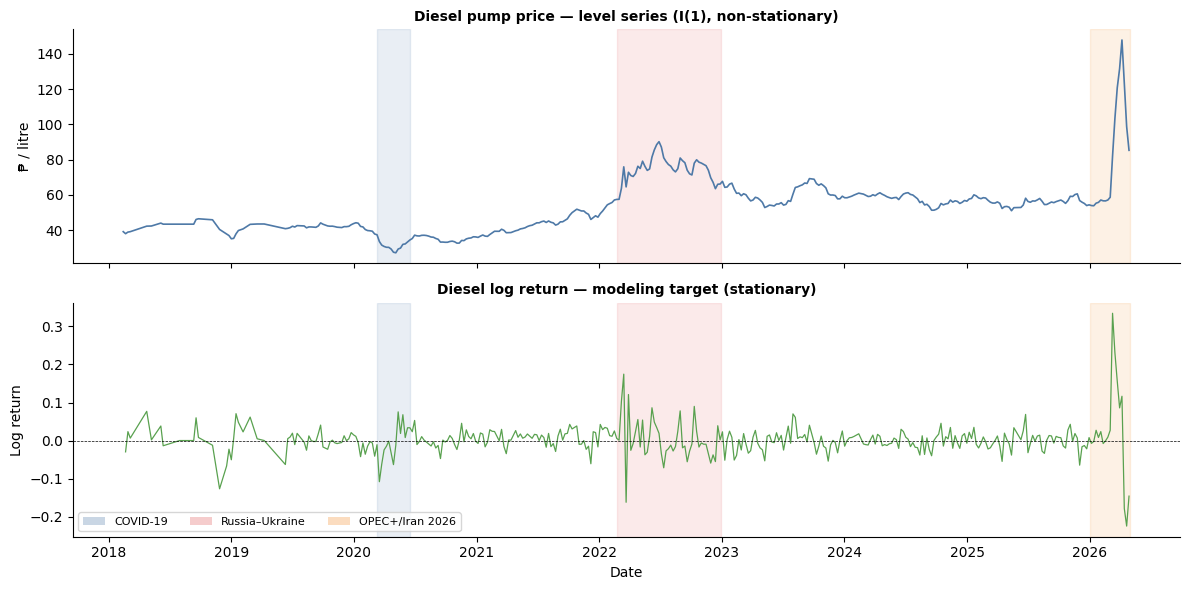

→ Notebook 04 predicts diesel_log_ret.
  Back-transform: price_t = price_{t-1} × exp(log_ret_hat)


In [5]:
# ── Visualise: levels vs log returns ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.subplots_adjust(hspace=0.08)

ax = axes[0]
ax.plot(df.index, df[TARGET_PRODUCT], color='#4e79a7', linewidth=1.2)
shade_crises(ax)
ax.set_ylabel('₱ / litre', fontsize=10)
ax.set_title('Diesel pump price — level series (I(1), non-stationary)',
             fontsize=10, fontweight='bold')

ax = axes[1]
ax.plot(df['diesel_log_ret'].dropna().index,
        df['diesel_log_ret'].dropna(),
        color='#59a14f', linewidth=0.9)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
shade_crises(ax)
ax.set_ylabel('Log return', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.set_title('Diesel log return — modeling target (stationary)', fontsize=10, fontweight='bold')

for ax in axes:
    fmt_xaxis(ax)

# Crisis legend on bottom panel only
handles = [plt.Rectangle((0, 0), 1, 1, fc=c, alpha=0.3)
           for _, _, c, _ in CRISIS_BANDS]
labels  = [lbl for _, _, _, lbl in CRISIS_BANDS]
axes[1].legend(handles, labels, fontsize=8, loc='lower left', ncol=3)

plt.tight_layout()
plt.show()

print('→ Notebook 04 predicts diesel_log_ret.')
print('  Back-transform: price_t = price_{t-1} × exp(log_ret_hat)')


---
## Section 4 — Derived Features

All derived features are computed on the **raw (unlagged) series** at this stage.
The lag shift is applied systematically in Section 5. This separation makes the
construction logic transparent and avoids confusion between the feature value and
its temporal placement relative to the target.

### 4.1 Crack spread (refining margin)

The crack spread is the difference between the price of a refined petroleum product and its
crude oil feedstock. It measures the refining margin — the economic incentive for refiners.
For diesel, the relevant spread is gasoil (distillate) minus crude:

$$\text{crack\_spread}_t = \text{MOPS gasoil}_t - \text{Brent}_t$$

The sign convention is critical: **refined product minus crude**. A positive crack spread
indicates a profitable refining environment; a rising crack spread signals upstream cost
pressure that precedes pump price increases. The earlier notebook had this inverted
(Brent − MOPS), which reverses the economic interpretation.

Note: MOPS is used here only to compute the crack spread as a derived signal, not as a
direct input. The professor's leakage concern applies to using MOPS gasoil as a direct
price proxy for the DOE formula; using it as one component of a spread is defensible
because the spread captures a *margin* not available from crude alone.


In [6]:
# ── 4.1 Crack spread: MOPS gasoil minus Brent ─────────────────────────────
# Sign: refined product − crude = refining margin (positive = profitable)
if 'mops_gasoil_mean' in df.columns and 'brent_mean' in df.columns:
    df['crack_spread'] = df['mops_gasoil_mean'] - df['brent_mean']
    print(f'crack_spread constructed: mean = {df["crack_spread"].mean():.2f}, '
          f'std = {df["crack_spread"].std():.2f}')
    print(f'  Positive values = {(df["crack_spread"] > 0).sum()} / {len(df)} weeks')
else:
    raise KeyError('mops_gasoil_mean or brent_mean not found in master frame.')


crack_spread constructed: mean = 18.47, std = 13.66
  Positive values = 373 / 373 weeks


### 4.2 Brent log return

The upstream crude signal, transformed to log returns for stationarity. This is the
dimensionless rate-of-change version of Brent that feeds directly into the RFH asymmetric
decomposition below.


In [7]:
# ── 4.2 Brent log return ───────────────────────────────────────────────────
df['brent_log_ret'] = np.log(df['brent_mean'] / df['brent_mean'].shift(1))

print(f'brent_log_ret: mean = {df["brent_log_ret"].mean():.5f}, '
      f'std = {df["brent_log_ret"].std():.5f}')


brent_log_ret: mean = 0.00155, std = 0.05713


### 4.3 Asymmetric crude change — rockets and feathers (Wen et al., 2025)

The rockets-and-feathers hypothesis (Borenstein et al., 1997; Wen et al., 2025) posits that
retail fuel prices respond asymmetrically to upstream crude: they rise quickly when crude
rises ("rockets") and fall slowly when crude falls ("feathers"). To test and model this
asymmetry, the Brent log return is decomposed into positive and negative components:

$$r^+_t = \max(\Delta\log\text{Brent}_t,\ 0), \quad r^-_t = \min(\Delta\log\text{Brent}_t,\ 0)$$

A symmetric model imposes $\beta^+ = \beta^-$; the RFH hypothesis predicts $|\beta^+| > |\beta^-|$
(stronger pass-through for price increases). Both components are included so the model can
estimate these coefficients freely.


In [8]:
# ── 4.3 Asymmetric Brent decomposition (RFH) ──────────────────────────────
df['brent_chg_pos'] = df['brent_log_ret'].clip(lower=0)   # positive shocks only
df['brent_chg_neg'] = df['brent_log_ret'].clip(upper=0)   # negative shocks only

# Sanity: pos + neg must equal original exactly
residual = (df['brent_chg_pos'] + df['brent_chg_neg'] - df['brent_log_ret']).abs().max()
assert residual < 1e-12, f'Asymmetric decomposition residual too large: {residual}'

print('Asymmetric decomposition check passed.')
print(f'  brent_chg_pos: mean = {df["brent_chg_pos"].mean():.5f}  '
      f'(zero-valued {(df["brent_chg_pos"]==0).sum()} weeks)')
print(f'  brent_chg_neg: mean = {df["brent_chg_neg"].mean():.5f}  '
      f'(zero-valued {(df["brent_chg_neg"]==0).sum()} weeks)')


Asymmetric decomposition check passed.
  brent_chg_pos: mean = 0.01957  (zero-valued 163 weeks)
  brent_chg_neg: mean = -0.01801  (zero-valued 209 weeks)


### 4.4 Peso-cost of crude (brent_php)

The actual cost burden on Philippine fuel importers is not Brent in USD but Brent converted
to Philippine pesos. This interaction captures the *joint* effect of crude price and exchange
rate movements — a dollar depreciation and a crude spike together cause a larger cost shock
than either alone. The log return of `brent_php` is the single most theoretically grounded
feature for Philippine pump price pass-through.

$$\text{brent\_php}_t = \text{Brent}_{t}^{\text{USD}} \times \text{USD/PHP}_t$$
$$r^{\text{brent\_php}}_t = \Delta\log(\text{brent\_php}_t)$$


In [9]:
# ── 4.4 Peso-denominated crude cost ───────────────────────────────────────
df['brent_php']         = df['brent_mean'] * df['usd_php_mean']
df['brent_php_log_ret'] = np.log(df['brent_php'] / df['brent_php'].shift(1))

print(f'brent_php        : mean = {df["brent_php"].mean():.2f} ₱/bbl')
print(f'brent_php_log_ret: mean = {df["brent_php_log_ret"].mean():.5f}, '
      f'std = {df["brent_php_log_ret"].std():.5f}')


brent_php        : mean = 3999.66 ₱/bbl
brent_php_log_ret: mean = 0.00198, std = 0.05796


### 4.5 Week-on-week percentage changes

These are the rate-of-change (dimensionless, in %) versions of Brent and USD/PHP.
They are stationary by construction and serve as a consistent unit for model inputs
alongside the log-return target.


In [10]:
# ── 4.5 WoW percentage changes ─────────────────────────────────────────────
df['brent_pct_1w']  = df['brent_mean'].pct_change(1) * 100
df['usdphp_pct_1w'] = df['usd_php_mean'].pct_change(1) * 100

print(f'brent_pct_1w  : mean = {df["brent_pct_1w"].mean():.3f}%, '
      f'std = {df["brent_pct_1w"].std():.3f}%')
print(f'usdphp_pct_1w : mean = {df["usdphp_pct_1w"].mean():.3f}%, '
      f'std = {df["usdphp_pct_1w"].std():.3f}%')


brent_pct_1w  : mean = 0.317%, std = 5.668%
usdphp_pct_1w : mean = 0.045%, std = 0.670%


### 4.6 Diesel log-return momentum

Momentum captures serial dependence in the direction of price changes — periods where prices
trend up or down consecutively. Computed as pct_change of the **diesel price level** to match
units with the log-return target (both dimensionless). The 1-week and 2-week windows align
with the lag structure used for own-price autocorrelation.


In [11]:
# ── 4.6 Diesel momentum (% change, dimensionless) ─────────────────────────
# pct_change gives a dimensionless ratio consistent with the log-return target
df['diesel_mom_1w'] = df[TARGET_PRODUCT].pct_change(1)
df['diesel_mom_2w'] = df[TARGET_PRODUCT].pct_change(2)

print(f'diesel_mom_1w: mean = {df["diesel_mom_1w"].mean():.5f}, '
      f'std = {df["diesel_mom_1w"].std():.5f}')
print(f'diesel_mom_2w: mean = {df["diesel_mom_2w"].mean():.5f}, '
      f'std = {df["diesel_mom_2w"].std():.5f}')


diesel_mom_1w: mean = 0.00302, std = 0.04424
diesel_mom_2w: mean = 0.00724, std = 0.07614


### 4.7 Realized volatility of Brent

Rolling standard deviation of Brent log returns, annualised by $\times\sqrt{52}$.
Captures the variance regime of the upstream crude market. Two windows are used:
4-week (short-run) and 12-week (medium-run), motivated by the 12-week optimal lookback
identified in HARLSTM (2023) and Eliwa (2024).


In [12]:
# ── 4.7 Realized volatility of Brent ──────────────────────────────────────
df['brent_vol_4w']  = df['brent_log_ret'].rolling(4).std()  * np.sqrt(52)
df['brent_vol_12w'] = df['brent_log_ret'].rolling(12).std() * np.sqrt(52)

print(f'brent_vol_4w  (annualised): mean = {df["brent_vol_4w"].mean():.4f}')
print(f'brent_vol_12w (annualised): mean = {df["brent_vol_12w"].mean():.4f}')


brent_vol_4w  (annualised): mean = 0.2816
brent_vol_12w (annualised): mean = 0.3260


### 4.8 TRAIN Law excise impulse

The Tax Reform for Acceleration and Inclusion (TRAIN, RA 10963) introduced a three-tranche
excise tax on petroleum products effective 2018–2020. The excise level is embedded in all
observed pump prices, so it carries no signal for the log-return model when held constant.
However, at each tranche transition a one-week discrete jump occurs that is directly
attributable to the policy change. This is captured as a one-week impulse variable equal
to the peso-per-litre increment at each tranche boundary.

| Effectivity | Diesel increment (₱/L) |
|---|---|
| Jan 2019 | +1.85 |
| Jan 2020 | +1.50 |

The impulse fires for exactly one week at each transition, matching the DOE bulletin cycle.


In [13]:
# ── 4.8 TRAIN Law excise impulse ──────────────────────────────────────────
# Tranche schedule for diesel (RA 10963)
EXCISE_SCHEDULE = {2018: 2.65, 2019: 4.50, 2020: 6.00}

def excise_level(date):
    yr = date.year
    if   yr >= 2020: return EXCISE_SCHEDULE[2020]
    elif yr >= 2019: return EXCISE_SCHEDULE[2019]
    elif yr >= 2018: return EXCISE_SCHEDULE[2018]
    else:            return 0.0

df['excise_diesel_level'] = [excise_level(d) for d in df.index]

# Impulse = week-on-week change in excise level; zero except at tranche transitions
df['excise_diesel_impulse'] = df['excise_diesel_level'].diff().fillna(0.0)

transitions = df[df['excise_diesel_impulse'] != 0][['excise_diesel_level', 'excise_diesel_impulse']]
print('Excise impulse events (TRAIN Law tranche transitions):')
print(transitions.to_string())
print()
print('Note: the level column is retained for reference but NOT used as a model feature.')
print('      Only the impulse column enters the feature matrix.')


Excise impulse events (TRAIN Law tranche transitions):
            excise_diesel_level  excise_diesel_impulse
2019-01-01                  4.5                   1.85
2020-01-07                  6.0                   1.50

Note: the level column is retained for reference but NOT used as a model feature.
      Only the impulse column enters the feature matrix.


---
## Section 5 — Visual Summary of Derived Features

All derived features plotted over time to validate construction and confirm expected
behaviour during crisis periods (shaded bands).


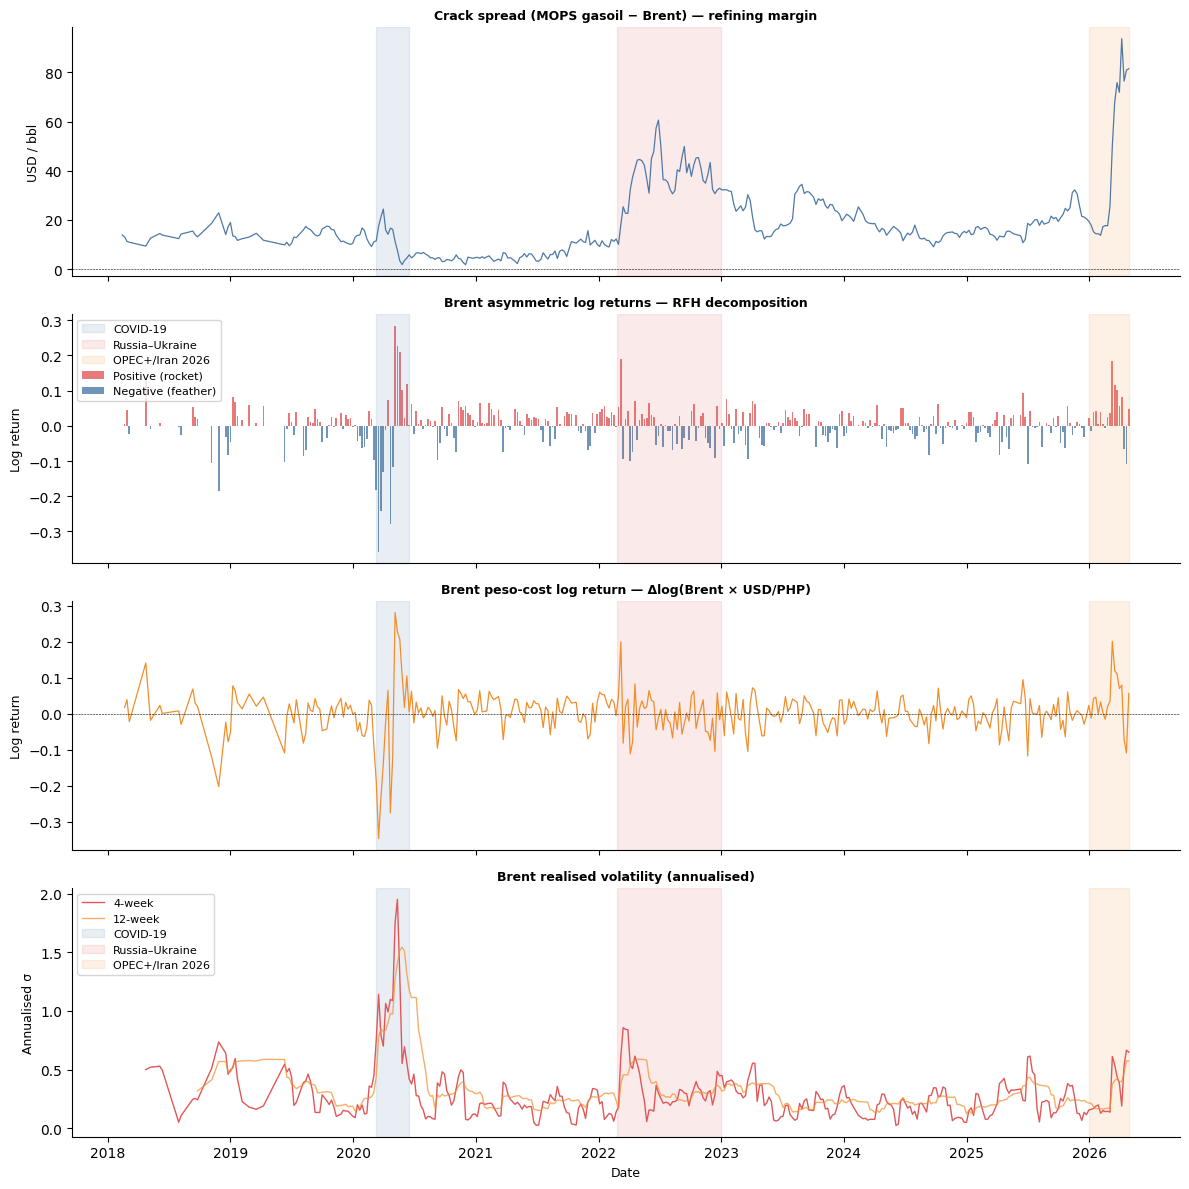

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig.subplots_adjust(hspace=0.08)

# Panel 0: Crack spread
axes[0].plot(df.index, df['crack_spread'], color='#4e79a7', linewidth=0.9)
axes[0].axhline(0, color='black', linewidth=0.4, linestyle='--')
shade_crises(axes[0])
axes[0].set_ylabel('USD / bbl', fontsize=9)
axes[0].set_title('Crack spread (MOPS gasoil − Brent) — refining margin', fontsize=9, fontweight='bold')

# Panel 1: Brent asymmetric returns
axes[1].bar(df.index, df['brent_chg_pos'], color='#e15759', width=5, alpha=0.8, label='Positive (rocket)')
axes[1].bar(df.index, df['brent_chg_neg'], color='#4e79a7', width=5, alpha=0.8, label='Negative (feather)')
shade_crises(axes[1])
axes[1].set_ylabel('Log return', fontsize=9)
axes[1].set_title('Brent asymmetric log returns — RFH decomposition', fontsize=9, fontweight='bold')
axes[1].legend(fontsize=8, loc='upper left')

# Panel 2: Brent_php log return
axes[2].plot(df.index, df['brent_php_log_ret'], color='#f28e2b', linewidth=0.9)
axes[2].axhline(0, color='black', linewidth=0.4, linestyle='--')
shade_crises(axes[2])
axes[2].set_ylabel('Log return', fontsize=9)
axes[2].set_title('Brent peso-cost log return — Δlog(Brent × USD/PHP)', fontsize=9, fontweight='bold')

# Panel 3: Realized vol
axes[3].plot(df.index, df['brent_vol_4w'],  color='#e15759', linewidth=1.0, label='4-week')
axes[3].plot(df.index, df['brent_vol_12w'], color='#f28e2b', linewidth=1.0, alpha=0.7, label='12-week')
shade_crises(axes[3])
axes[3].set_ylabel('Annualised σ', fontsize=9)
axes[3].set_xlabel('Date', fontsize=9)
axes[3].set_title('Brent realised volatility (annualised)', fontsize=9, fontweight='bold')
axes[3].legend(fontsize=8, loc='upper left')

for ax in axes:
    fmt_xaxis(ax)

plt.tight_layout()
plt.show()


---
## Section 6 — Lag Structure

**The fundamental leakage rule**: the DOE Tuesday bulletin announces the new pump price
effective that week. Any market data from the same week (Monday–Tuesday close) is observed
*before* the bulletin is published and could in principle be used by DOE to set prices —
but since we cannot know the exact intra-week timing, all market features are lagged by
**at least one week** (shift by 1). This is a conservative, defensible choice.

The lag horizon of 1–4 weeks is motivated by the cross-correlation function between upstream
signals and diesel log returns from the EDA (Section 5), which showed significant autocorrelation
decaying after approximately four lags.

Three groups of features receive different lag treatments:

| Group | Features | Lags |
|---|---|---|
| Market drivers | Brent lags, crack spread, FX, GRP, OVX, RFH components, vol, momentum, brent_php | 1–4 |
| Own-price | `diesel_log_ret` | 1–4 |
| Regime / event | Markov prob, crisis dummies, excise impulse | 1 only |


In [15]:
# ── Define which raw features get lagged and at what depth ─────────────────

# Market driver features — lagged 1–4
MARKET_FEATURES = [c for c in [
    'brent_log_ret',
    'brent_chg_pos',
    'brent_chg_neg',
    'brent_pct_1w',
    'brent_php_log_ret',
    'crack_spread',
    'usdphp_pct_1w',
    'diesel_mom_1w',
    'diesel_mom_2w',
    'brent_vol_4w',
    'brent_vol_12w',
    'ovx_mean',
    'GPR_OIL',
] if c in df.columns]

# Own-price log return — lagged 1–4
OWN_RETURN_FEATURE = 'diesel_log_ret'

# Regime/event features — lagged 1 only
REGIME_FEATURES = [c for c in [
    'markov_prob_highvol',
    'd_covid',
    'd_ukraine',
    'd_iran26',
    'excise_diesel_impulse',
] if c in df.columns]

print(f'Market features  (lags 1–4): {len(MARKET_FEATURES)}')
for f in MARKET_FEATURES:
    print(f'  {f}')
print()
print(f'Own-return feature (lags 1–4): {OWN_RETURN_FEATURE}')
print()
print(f'Regime features  (lag 1 only): {len(REGIME_FEATURES)}')
for f in REGIME_FEATURES:
    print(f'  {f}')


Market features  (lags 1–4): 13
  brent_log_ret
  brent_chg_pos
  brent_chg_neg
  brent_pct_1w
  brent_php_log_ret
  crack_spread
  usdphp_pct_1w
  diesel_mom_1w
  diesel_mom_2w
  brent_vol_4w
  brent_vol_12w
  ovx_mean
  GPR_OIL

Own-return feature (lags 1–4): diesel_log_ret

Regime features  (lag 1 only): 5
  markov_prob_highvol
  d_covid
  d_ukraine
  d_iran26
  excise_diesel_impulse


In [16]:
# ── Create all lag columns ─────────────────────────────────────────────────
lag_cols_created = []

# Market features: lags 1–4
for col in MARKET_FEATURES:
    for lag in LAGS:
        new_col = f'{col}_lag{lag}'
        df[new_col] = df[col].shift(lag)
        lag_cols_created.append(new_col)

# Own log return: lags 1–4
for lag in LAGS:
    new_col = f'{OWN_RETURN_FEATURE}_lag{lag}'
    df[new_col] = df[OWN_RETURN_FEATURE].shift(lag)
    lag_cols_created.append(new_col)

# Regime features: lag 1 only
for col in REGIME_FEATURES:
    new_col = f'{col}_lag1'
    df[new_col] = df[col].shift(1)
    lag_cols_created.append(new_col)

print(f'Lag columns created: {len(lag_cols_created)}')
print(f'Total df columns   : {df.shape[1]}')

# Drop construction rows with NaN from lag-4 window
rows_before = len(df)
df = df.dropna(subset=['brent_log_ret_lag4'])
print(f'Rows dropped (lag-4 NaN window): {rows_before - len(df)}')
print(f'Remaining rows : {len(df)}')
print(f'Date range     : {df.index.min().date()}  →  {df.index.max().date()}')


Lag columns created: 61
Total df columns   : 110
Rows dropped (lag-4 NaN window): 5
Remaining rows : 368
Date range     : 2018-05-08  →  2026-04-28


---
## Section 7 — p-value Screening

Following Lunor et al. (2023, Section 2.2), each candidate feature is tested individually
against the diesel log return target using a univariate OLS regression. Features with a
two-tailed p-value below α = 0.05 are retained for the multivariate model.

**Screening applies only to candidate lag-1 market features.** Own-price lags and regime
features are included unconditionally — their relevance is established a priori by the
autocorrelation analysis (EDA Section 6) and theoretical motivation (crisis dummies).
This matches the Lunor et al. methodology of pre-screening before PCA.


In [17]:
def pvalue_screen(df, target, candidates, alpha=0.05):
    """
    Univariate OLS p-value test.

    Each candidate feature is regressed independently against the target.
    Returns a DataFrame sorted by p-value with a significance flag.

    Parameters
    ----------
    df         : DataFrame containing target and candidate columns
    target     : str, name of the target column
    candidates : list of str, candidate feature columns
    alpha      : float, significance threshold (default 0.05)

    Returns
    -------
    DataFrame with columns: feature, beta, p_value, significant
    """
    data = df[[target] + [c for c in candidates if c in df.columns]].dropna()
    y    = data[target].values
    results = []

    for feat in candidates:
        if feat not in data.columns:
            continue
        Xc     = np.column_stack([np.ones(len(data)), data[feat].values])
        beta   = np.linalg.lstsq(Xc, y, rcond=None)[0]
        resid  = y - Xc @ beta
        n, k   = Xc.shape
        s2     = (resid @ resid) / (n - k)
        se     = np.sqrt(np.diag(s2 * np.linalg.inv(Xc.T @ Xc)))
        t_stat = beta / se
        p_val  = 2 * (1 - t_dist.cdf(np.abs(t_stat[1]), df=n - k))
        results.append({
            'feature':     feat,
            'beta':        round(beta[1], 6),
            'p_value':     round(p_val, 6),
            'significant': p_val < alpha,
        })

    return pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)


# Candidate features for p-value screening: lag-1 versions of market features
CANDIDATES_LAG1 = [f'{c}_lag1' for c in MARKET_FEATURES if f'{c}_lag1' in df.columns]

pval_df = pvalue_screen(df, 'diesel_log_ret', CANDIDATES_LAG1)
sig_feats = pval_df[pval_df['significant']]['feature'].tolist()

print(f'p-value screening  |  target: diesel_log_ret  |  α = 0.05')
print(f'Significant: {len(sig_feats)} / {len(CANDIDATES_LAG1)} candidates')
print()
print(pval_df.to_string(index=False))


p-value screening  |  target: diesel_log_ret  |  α = 0.05
Significant: 10 / 13 candidates

               feature      beta  p_value  significant
    brent_log_ret_lag1  0.372073 0.000000         True
    brent_chg_pos_lag1  0.586812 0.000000         True
    brent_chg_neg_lag1  0.393630 0.000000         True
     brent_pct_1w_lag1  0.003809 0.000000         True
brent_php_log_ret_lag1  0.373653 0.000000         True
    diesel_mom_1w_lag1  0.366971 0.000000         True
    diesel_mom_2w_lag1  0.196180 0.000000         True
          GPR_OIL_lag1  0.000027 0.001236         True
    usdphp_pct_1w_lag1  0.008404 0.013995         True
     crack_spread_lag1 -0.000359 0.032780         True
    brent_vol_12w_lag1  0.004599 0.658862        False
         ovx_mean_lag1  0.000044 0.680425        False
     brent_vol_4w_lag1 -0.001987 0.843984        False


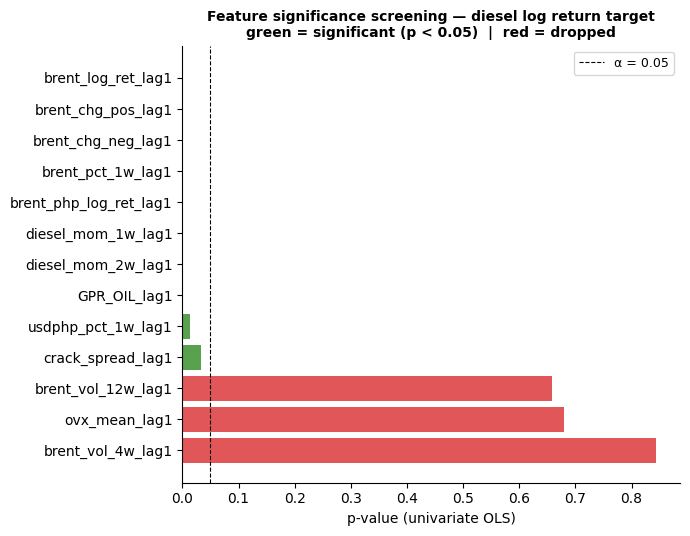

Significant features retained: ['brent_log_ret_lag1', 'brent_chg_pos_lag1', 'brent_chg_neg_lag1', 'brent_pct_1w_lag1', 'brent_php_log_ret_lag1', 'diesel_mom_1w_lag1', 'diesel_mom_2w_lag1', 'GPR_OIL_lag1', 'usdphp_pct_1w_lag1', 'crack_spread_lag1']
Dropped: ['brent_vol_12w_lag1', 'ovx_mean_lag1', 'brent_vol_4w_lag1']


In [18]:
# ── p-value bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, max(4, len(pval_df) * 0.42)))

colors = ['#59a14f' if s else '#e15759' for s in pval_df['significant']]
ax.barh(pval_df['feature'][::-1], pval_df['p_value'][::-1],
        color=colors[::-1], edgecolor='none')
ax.axvline(0.05, color='black', linestyle='--', linewidth=0.8, label='α = 0.05')

ax.set_xlabel('p-value (univariate OLS)', fontsize=10)
ax.set_title('Feature significance screening — diesel log return target\n'
             'green = significant (p < 0.05)  |  red = dropped', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Significant features retained: {sig_feats}')
print(f'Dropped: {pval_df[~pval_df["significant"]]["feature"].tolist()}')


---
## Section 8 — Assembling the Feature Set

The final feature set is the union of:

1. **Unconditional features** — included regardless of p-value because they have strong
   a priori theoretical justification (own-price autocorrelation, regime/crisis dummies).
2. **Significant lag-1 features** — those passing the p-value screen in Section 7.
3. **Extended lags (2–4)** for market features that were significant at lag 1 — retaining
   the full lag structure motivated by the CCF analysis.

The lag-1–4 own-price log return captures serial autocorrelation and directly
addresses the AR(1) critique (a model that only uses lag-1 price is naive;
incorporating four lags at minimum tests whether additional lag structure improves
on the AR(1) baseline).


In [19]:
# ── Unconditional features (bypass p-value screen) ────────────────────────
UNCONDITIONAL = list(dict.fromkeys([f for f in (
    # Own-price log return: lags 1–4
    [f'diesel_log_ret_lag{l}' for l in LAGS] +
    # Regime / event: lag 1 only
    [f'{c}_lag1' for c in REGIME_FEATURES] +
    # RFH asymmetric: lags 1–4 (strong prior from literature)
    [f'brent_chg_pos_lag{l}' for l in LAGS] +
    [f'brent_chg_neg_lag{l}' for l in LAGS]
) if f in df.columns]))

# ── Extend significant lag-1 features to lags 2–4 ─────────────────────────
# For each feature that passed at lag-1, include lags 2, 3, 4 as well
sig_base_features = [f.replace('_lag1', '') for f in sig_feats]
sig_extended = [f'{base}_lag{l}'
                for base in sig_base_features
                for l in LAGS
                if f'{base}_lag{l}' in df.columns]

# ── Final feature set (deduplicated) ──────────────────────────────────────
FINAL_FEATURES = list(dict.fromkeys(UNCONDITIONAL + sig_feats + sig_extended))
FINAL_FEATURES = [f for f in FINAL_FEATURES if f in df.columns]

print(f'Unconditional features       : {len(UNCONDITIONAL)}')
print(f'Significant lag-1 candidates : {len(sig_feats)}')
print(f'Sig. features extended lag2–4: {len([f for f in sig_extended if f not in set(UNCONDITIONAL+sig_feats)])}')
print(f'Final feature set (total)    : {len(FINAL_FEATURES)}')
print()
print('Final features:')
for f in FINAL_FEATURES:
    print(f'  {f}')


Unconditional features       : 17
Significant lag-1 candidates : 10
Sig. features extended lag2–4: 24
Final feature set (total)    : 49

Final features:
  diesel_log_ret_lag1
  diesel_log_ret_lag2
  diesel_log_ret_lag3
  diesel_log_ret_lag4
  markov_prob_highvol_lag1
  d_covid_lag1
  d_ukraine_lag1
  d_iran26_lag1
  excise_diesel_impulse_lag1
  brent_chg_pos_lag1
  brent_chg_pos_lag2
  brent_chg_pos_lag3
  brent_chg_pos_lag4
  brent_chg_neg_lag1
  brent_chg_neg_lag2
  brent_chg_neg_lag3
  brent_chg_neg_lag4
  brent_log_ret_lag1
  brent_pct_1w_lag1
  brent_php_log_ret_lag1
  diesel_mom_1w_lag1
  diesel_mom_2w_lag1
  GPR_OIL_lag1
  usdphp_pct_1w_lag1
  crack_spread_lag1
  brent_log_ret_lag2
  brent_log_ret_lag3
  brent_log_ret_lag4
  brent_pct_1w_lag2
  brent_pct_1w_lag3
  brent_pct_1w_lag4
  brent_php_log_ret_lag2
  brent_php_log_ret_lag3
  brent_php_log_ret_lag4
  diesel_mom_1w_lag2
  diesel_mom_1w_lag3
  diesel_mom_1w_lag4
  diesel_mom_2w_lag2
  diesel_mom_2w_lag3
  diesel_mom_2w_lag4

---
## Section 9 — VIF Screening (Pre-PCA)

Variance Inflation Factors are computed on the full candidate feature set to identify
multicollinear groups. Features with VIF > 10 are candidates for PCA compression; features
with VIF < 5 can enter the model directly. This step informs the PCA block design in
Section 10.


In [20]:
X_vif    = df[FINAL_FEATURES].dropna()
vif_vals = [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]

vif_df = pd.DataFrame({
    'feature': FINAL_FEATURES,
    'VIF':     vif_vals
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF — Final feature set (pre-PCA)')
print('-' * 48)
print(vif_df.to_string(index=False))
print()
n_high = (vif_df['VIF'] > 10).sum()
print(f'Features with VIF > 10 : {n_high}  → candidates for PCA compression')
print(f'Features with VIF < 5  : {(vif_df["VIF"] < 5).sum()}  → enter model directly')


VIF — Final feature set (pre-PCA)
------------------------------------------------
                   feature          VIF
        brent_chg_pos_lag3          inf
        brent_chg_pos_lag2          inf
        brent_log_ret_lag3          inf
        brent_log_ret_lag4          inf
        brent_log_ret_lag1          inf
        brent_chg_neg_lag4          inf
        brent_chg_neg_lag3          inf
        brent_chg_neg_lag2          inf
        brent_chg_neg_lag1          inf
        brent_chg_pos_lag4          inf
        brent_log_ret_lag2          inf
        brent_chg_pos_lag1          inf
    brent_php_log_ret_lag4 3.111898e+06
    brent_php_log_ret_lag2 3.057855e+06
    brent_php_log_ret_lag3 3.047475e+06
    brent_php_log_ret_lag1 2.988504e+06
        usdphp_pct_1w_lag4 4.173189e+04
        usdphp_pct_1w_lag2 4.077234e+04
        usdphp_pct_1w_lag3 4.066182e+04
        usdphp_pct_1w_lag1 4.006097e+04
        diesel_mom_1w_lag2 1.612089e+03
        diesel_mom_1w_lag4 1.575301e+

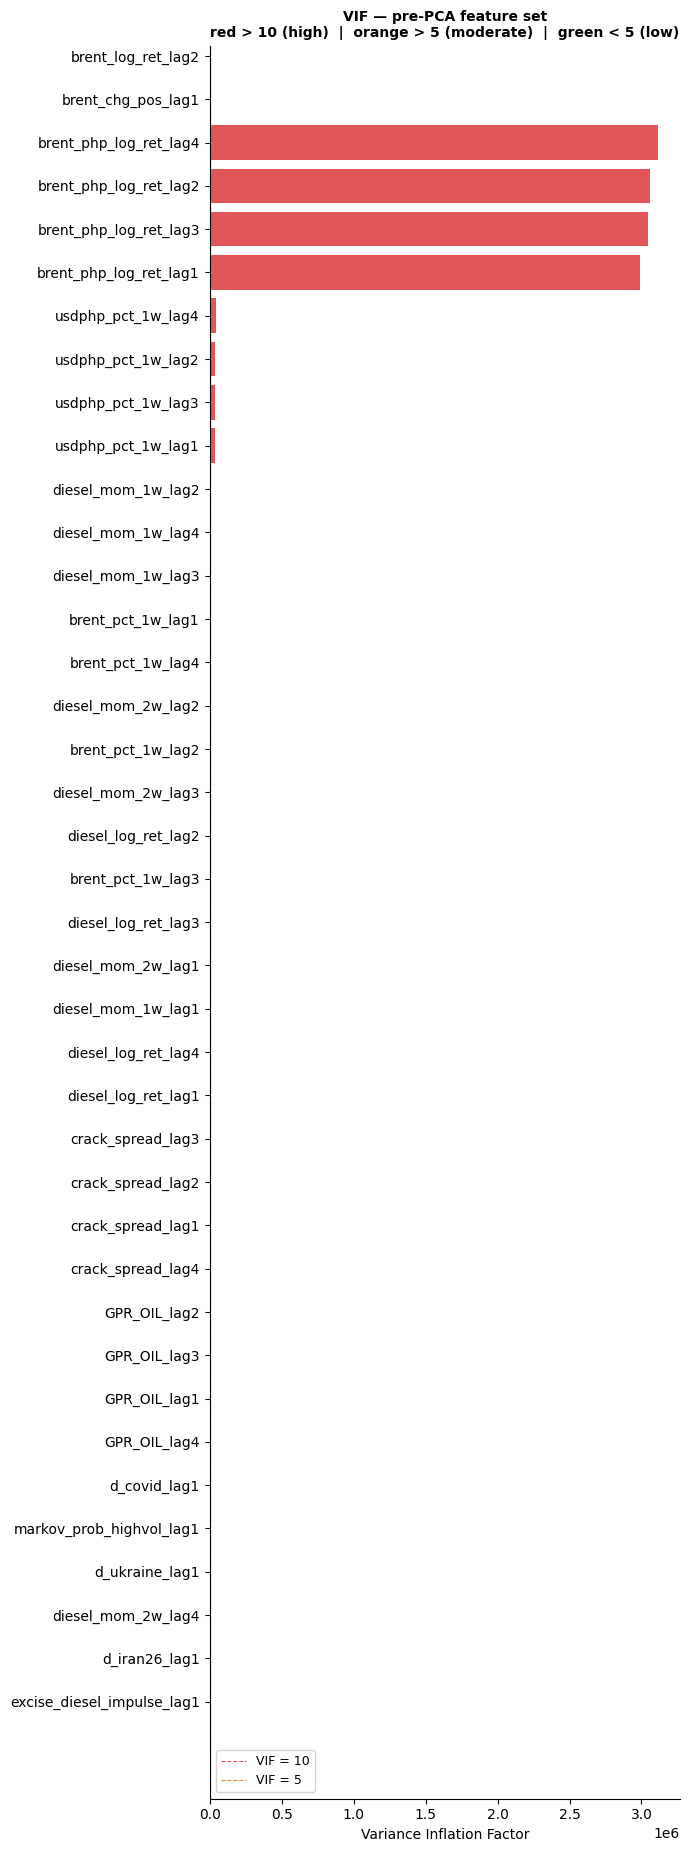

In [21]:
# ── VIF bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, max(4, len(vif_df) * 0.38)))

color_vif = ['#e15759' if v > 10 else '#f28e2b' if v > 5 else '#59a14f'
             for v in vif_df['VIF']]
ax.barh(vif_df['feature'][::-1], vif_df['VIF'][::-1],
        color=color_vif[::-1], edgecolor='none')
ax.axvline(10, color='#e15759', linestyle='--', linewidth=0.8, label='VIF = 10')
ax.axvline(5,  color='#f28e2b', linestyle='--', linewidth=0.8, label='VIF = 5')

ax.set_xlabel('Variance Inflation Factor', fontsize=10)
ax.set_title('VIF — pre-PCA feature set\n'
             'red > 10 (high)  |  orange > 5 (moderate)  |  green < 5 (low)', fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## Section 10 — PCA on the Crude Lag Block

The lagged crude oil features (Brent log return, crack spread, Brent–PHP log return, lags 1–4)
are highly collinear — they measure the same upstream signal at different time offsets. Rather
than including all twelve columns, we compress them into a small number of **principal
components** that collectively explain 95% of their variance, following Lunor et al. (2023,
Section 2.2).

**Important**: PCA is *fitted on training data only* inside each cross-validation fold in
Notebook 04. The `StandardScaler` and `PCA` objects saved here are for reference and
diagnostic visualisation. They must **not** be applied to test folds to avoid data leakage.

The procedure mirrors the professor's notebook exactly:

1. Standardise to zero mean and unit variance (`StandardScaler`).
2. Fit `PCA()` on the standardised matrix.
3. Plot cumulative explained variance using `plot_cum_exp_var` from `utils.py`.
4. Choose the number of components at the 95% threshold.
5. Visualise PC loadings using `plot_principal_components` from `utils.py`.


In [22]:
# ── Define the crude lag block ─────────────────────────────────────────────
CRUDE_PCA_BASE = [c for c in [
    'brent_log_ret',
    'crack_spread',
    'brent_php_log_ret',
] if c in df.columns]

crude_lag_block = [f'{c}_lag{l}'
                   for c in CRUDE_PCA_BASE
                   for l in LAGS
                   if f'{c}_lag{l}' in df.columns]

print(f'Crude lag block: {len(crude_lag_block)} columns')
for c in crude_lag_block:
    print(f'  {c}')


Crude lag block: 12 columns
  brent_log_ret_lag1
  brent_log_ret_lag2
  brent_log_ret_lag3
  brent_log_ret_lag4
  crack_spread_lag1
  crack_spread_lag2
  crack_spread_lag3
  crack_spread_lag4
  brent_php_log_ret_lag1
  brent_php_log_ret_lag2
  brent_php_log_ret_lag3
  brent_php_log_ret_lag4


In [23]:
# ── Standardise and fit PCA ────────────────────────────────────────────────
pca_data = df[crude_lag_block].dropna()

scaler   = StandardScaler()
X_std    = scaler.fit_transform(pca_data)

pca      = PCA()
pca.fit(X_std)

evr      = pca.explained_variance_ratio_
cum_var  = np.cumsum(evr)
n_95     = int(np.argmax(cum_var >= 0.95) + 1)
n_99     = int(np.argmax(cum_var >= 0.99) + 1)

print('Variance explained per principal component:')
print(f'  {"PC":<6}  {"Individual":>12}  {"Cumulative":>12}')
print(f'  {"-"*34}')
for i, (ev, cv) in enumerate(zip(evr, cum_var)):
    marker = ' ← 95%' if (i+1) == n_95 else (' ← 99%' if (i+1) == n_99 else '')
    print(f'  PC{i+1:<4}  {ev:12.4f}  {cv:12.4f}{marker}')
    if cv > 0.999:
        break

print()
print(f'Retain {n_95} components at 95% variance threshold')
print(f'Compression: {len(crude_lag_block)} columns → {n_95} components')


Variance explained per principal component:
  PC        Individual    Cumulative
  ----------------------------------
  PC1           0.3193        0.3193
  PC2           0.2855        0.6048
  PC3           0.1758        0.7806
  PC4           0.1205        0.9011
  PC5           0.0803        0.9814 ← 95%
  PC6           0.0122        0.9936 ← 99%
  PC7           0.0027        0.9963
  PC8           0.0016        0.9979
  PC9           0.0007        0.9986
  PC10          0.0005        0.9992

Retain 5 components at 95% variance threshold
Compression: 12 columns → 5 components


### 10.1 Cumulative explained variance (professor's `plot_cum_exp_var`)


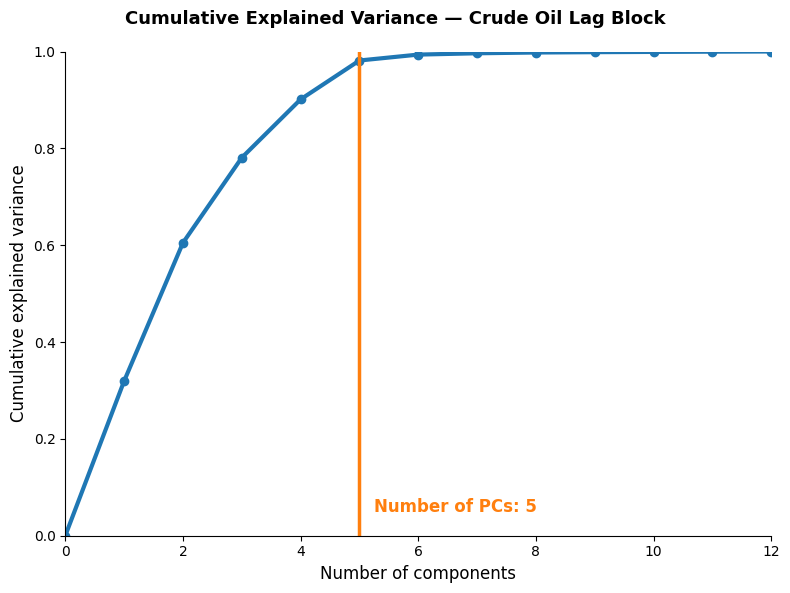

Number of PCs retained at 95%: 5


In [24]:
# Using professor's utility function directly
fig, ax, thresh = plot_cum_exp_var(pca.explained_variance_ratio_, tol=0.95)
fig.suptitle('Cumulative Explained Variance — Crude Oil Lag Block',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Number of PCs retained at 95%: {thresh}')


### 10.2 PC scatter and loading biplot (professor's `plot_principal_components`)

The biplot shows two panels:

- **Left**: Each observation projected onto PC1 and PC2. Points are coloured by diesel price
  level to assess whether the principal components track the price regime.
- **Right**: Loading vectors for each original feature. Features pointing in the same
  direction are positively correlated in this latent space; opposite directions indicate
  anticorrelation. The length of a vector indicates how strongly that feature contributes
  to the displayed PCs.


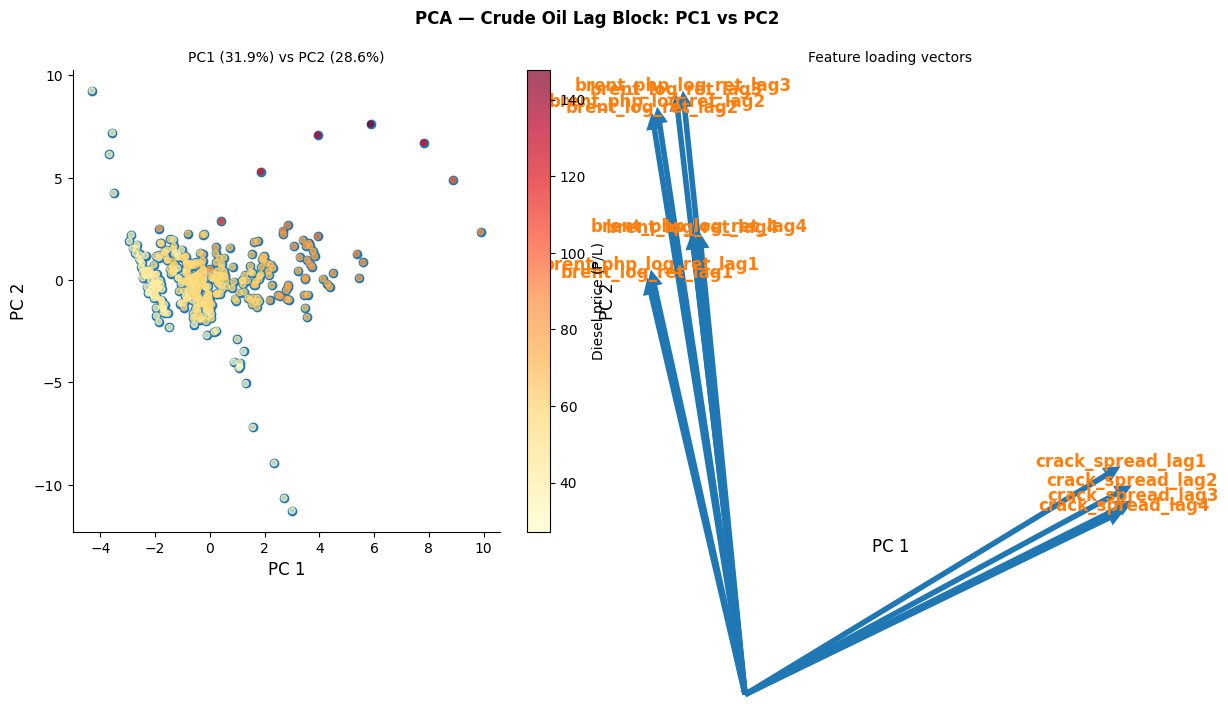

In [25]:
# Transform data and build DataFrames in the format expected by utils.py
X_pca        = pca.transform(X_std)
n_components = X_pca.shape[1]
pc_cols      = [f'PC {i+1}' for i in range(n_components)]

X_transformed = pd.DataFrame(X_pca, columns=pc_cols, index=pca_data.index)

# W must be (n_components × n_features) with PC names as index and feature names as columns
W = pd.DataFrame(pca.components_,
                 index=pc_cols,
                 columns=crude_lag_block)

# Colour by diesel level (aligned to PCA index)
diesel_aligned = df.loc[pca_data.index, TARGET_PRODUCT]

# Use plot_principal_components from utils.py
fig, axes = plot_principal_components(
    X_transformed, W,
    column_1='PC 1', column_2='PC 2',
    hue=None,
    figsize=(14, 6),
)

fig.suptitle('PCA — Crude Oil Lag Block: PC1 vs PC2', fontsize=12, fontweight='bold')

# Overlay diesel price as colour on the scatter (axes[0])
sc = axes[0].scatter(X_transformed['PC 1'], X_transformed['PC 2'],
                     c=diesel_aligned, cmap='YlOrRd', s=18, alpha=0.7, zorder=10)
plt.colorbar(sc, ax=axes[0], label='Diesel price (₱/L)')
axes[0].set_title(f'PC1 ({evr[0]*100:.1f}%) vs PC2 ({evr[1]*100:.1f}%)', fontsize=10)
axes[1].set_title('Feature loading vectors', fontsize=10)

plt.tight_layout()
plt.show()


In [26]:
# ── Validate PC1 interpretation ────────────────────────────────────────────
r_pc1_brent = np.corrcoef(X_transformed['PC 1'],
                           df.loc[pca_data.index, 'brent_mean'])[0, 1]
r_pc1_diesel = np.corrcoef(X_transformed['PC 1'],
                            df.loc[pca_data.index, TARGET_PRODUCT])[0, 1]

print('PC1 validation:')
print(f'  Correlation with Brent level : {r_pc1_brent:.4f}')
print(f'  Correlation with Diesel level: {r_pc1_diesel:.4f}')
print()
print('Interpretation:')
print('  PC1: all crude lag returns load with the same sign →')
print('       captures the global crude price TREND (momentum / level direction)')
print('  PC2: crack spread lags load opposite to Brent/PHP returns →')
print('       captures the refining MARGIN independent of crude direction')


PC1 validation:
  Correlation with Brent level : 0.5390
  Correlation with Diesel level: 0.7349

Interpretation:
  PC1: all crude lag returns load with the same sign →
       captures the global crude price TREND (momentum / level direction)
  PC2: crack spread lags load opposite to Brent/PHP returns →
       captures the refining MARGIN independent of crude direction


---
## Section 11 — Random Forest Feature Importance Diagnostic

A Random Forest is fit on all lag-1 features against the diesel log return target. This is a
**diagnostic only** — not the final model. Its purpose is to verify that the engineered
features register non-zero importance and that no unexpected dominant feature is present.

Features with near-zero importance across all 300 trees may be candidates for removal in
Notebook 04 model selection.


In [27]:
all_lag1_cols = [f for f in df.columns if '_lag1' in f]
X_rf = df[all_lag1_cols].dropna()
y_rf = df.loc[X_rf.index, 'diesel_log_ret'].dropna()
common_idx = X_rf.index.intersection(y_rf.index)
X_rf = X_rf.loc[common_idx]
y_rf = y_rf.loc[common_idx]

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf)

imp_df = (pd.DataFrame({'feature': X_rf.columns,
                         'importance': rf.feature_importances_})
           .sort_values('importance', ascending=False)
           .head(25)
           .reset_index(drop=True))

print('Top 25 features by RF importance (diagnostic only):')
print(imp_df.to_string(index=False))


Top 25 features by RF importance (diagnostic only):
                   feature  importance
              GPR_OIL_lag1    0.181506
         crack_spread_lag1    0.145617
  markov_prob_highvol_lag1    0.132662
    brent_php_log_ret_lag1    0.132330
        brent_log_ret_lag1    0.057524
         brent_pct_1w_lag1    0.052518
        brent_chg_pos_lag1    0.042101
         brent_vol_4w_lag1    0.037054
        diesel_mom_1w_lag1    0.035931
        brent_vol_12w_lag1    0.034450
       diesel_log_ret_lag1    0.034156
        diesel_mom_2w_lag1    0.033736
             ovx_mean_lag1    0.032096
        usdphp_pct_1w_lag1    0.026658
        brent_chg_neg_lag1    0.011286
             d_iran26_lag1    0.009057
            d_ukraine_lag1    0.001100
              d_covid_lag1    0.000189
excise_diesel_impulse_lag1    0.000028


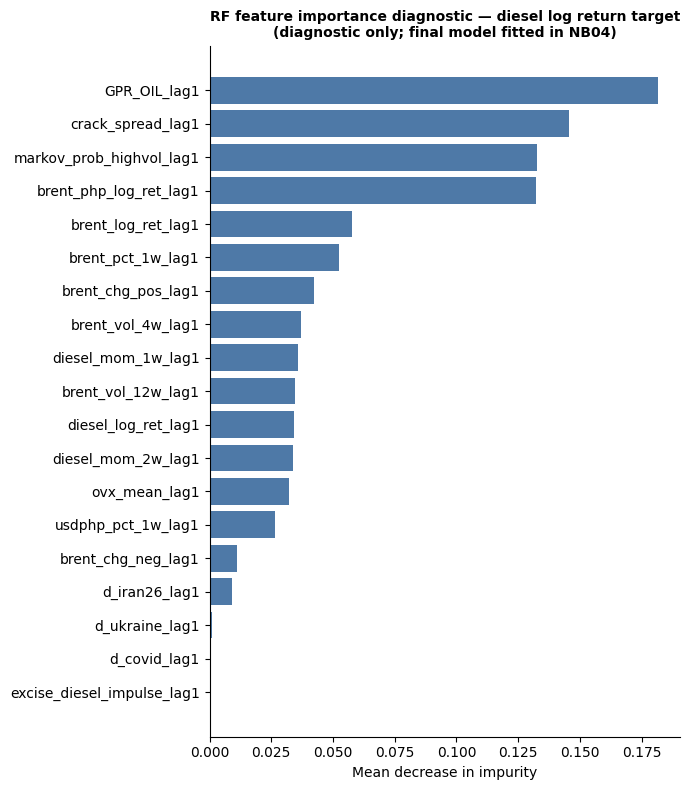

In [28]:
fig, ax = plt.subplots(figsize=(7, 8))

ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color='#4e79a7', edgecolor='none')
ax.set_xlabel('Mean decrease in impurity', fontsize=10)
ax.set_title('RF feature importance diagnostic — diesel log return target\n'
             '(diagnostic only; final model fitted in NB04)', fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## Section 12 — Save Master Frame and Feature Configuration

Two files are saved:

1. **`features_engineered.parquet`** — the full enriched DataFrame including the target
   (`diesel_log_ret`), the anchor level (`diesel`), all lagged features, and the crude lag
   block for PCA re-fitting inside CV folds.
2. **`feature_sets.json`** — a machine-readable specification listing the direct feature
   names, the crude PCA block columns, the number of PCA components to retain, and the
   back-transformation formula. Notebook 04 reads this file to reconstruct the feature
   matrix without re-running the engineering code.

> **Warning for NB04**: the `StandardScaler` and `PCA` fitted here are on the full
> available sample and must **not** be used to transform test data. They are saved to
> `pca_config.json` for reference only. Inside every CV fold, fit a new scaler and PCA on
> the training partition exclusively.


In [29]:
# ── Columns to save ────────────────────────────────────────────────────────
COLS_TO_SAVE = list(dict.fromkeys(
    [TARGET_PRODUCT, 'diesel_log_ret']   # target and back-transform anchor
    + FINAL_FEATURES                      # direct feature matrix
    + crude_lag_block                     # raw lag block → re-PCA inside CV folds
))
COLS_TO_SAVE = [c for c in COLS_TO_SAVE if c in df.columns]

df_save = df[COLS_TO_SAVE].copy()

print(f'Saving {len(COLS_TO_SAVE)} columns (from {df.shape[1]} total):')
print()
for c in COLS_TO_SAVE:
    null_count = df_save[c].isna().sum()
    print(f'  {c:<40}  nulls: {null_count}')


Saving 51 columns (from 110 total):

  diesel                                    nulls: 0
  diesel_log_ret                            nulls: 0
  diesel_log_ret_lag1                       nulls: 0
  diesel_log_ret_lag2                       nulls: 0
  diesel_log_ret_lag3                       nulls: 0
  diesel_log_ret_lag4                       nulls: 0
  markov_prob_highvol_lag1                  nulls: 0
  d_covid_lag1                              nulls: 0
  d_ukraine_lag1                            nulls: 0
  d_iran26_lag1                             nulls: 0
  excise_diesel_impulse_lag1                nulls: 0
  brent_chg_pos_lag1                        nulls: 0
  brent_chg_pos_lag2                        nulls: 0
  brent_chg_pos_lag3                        nulls: 0
  brent_chg_pos_lag4                        nulls: 0
  brent_chg_neg_lag1                        nulls: 0
  brent_chg_neg_lag2                        nulls: 0
  brent_chg_neg_lag3                        nulls: 0
  brent_c

In [30]:
# ── Write parquet ──────────────────────────────────────────────────────────
df_save.to_parquet('data/final/features_engineered.parquet')
print(f'Saved: features_engineered.parquet  —  shape {df_save.shape}')
print(f'Rows  : {len(df_save)}')
print(f'Dates : {df_save.index.min().date()}  →  {df_save.index.max().date()}')


Saved: features_engineered.parquet  —  shape (368, 51)
Rows  : 368
Dates : 2018-05-08  →  2026-04-28


In [31]:
# ── Write feature configuration JSON ──────────────────────────────────────
feature_config = {
    'diesel': {
        'target':             'diesel_log_ret',
        'level_anchor':       TARGET_PRODUCT,
        'direct_features':    FINAL_FEATURES,
        'crude_pca_block':    crude_lag_block,
        'n_pca_components':   int(n_95),
        'back_transform':     'price_t = price_{t-1} * exp(log_ret_hat)',
        'notes': (
            'All direct_features are already lagged and leakage-free. '
            'PCA must be re-fitted inside each CV fold on training data only. '
            'Never apply the scaler or PCA fitted here to test data.'
        ),
    }
}

with open('data/final/feature_sets.json', 'w') as fh:
    json.dump(feature_config, fh, indent=2)
print('Saved: feature_sets.json')

pca_config = {
    'crude_pca_block':     crude_lag_block,
    'n_components_95pct':  int(n_95),
    'warning': (
        'This config is for reference only. '
        'Re-fit StandardScaler + PCA on training data inside each CV fold in NB04.'
    ),
}
with open('data/final/pca_config.json', 'w') as fh:
    json.dump(pca_config, fh, indent=2)
print('Saved: pca_config.json')


Saved: feature_sets.json
Saved: pca_config.json


In [32]:
# ── Final sanity check ────────────────────────────────────────────────────
df_check = pd.read_parquet('data/final/features_engineered.parquet')

print('=' * 56)
print('FEATURE ENGINEERING — FINAL SANITY CHECK')
print('=' * 56)
print(f'Shape             : {df_check.shape}')
print(f'Date range        : {df_check.index.min().date()}  →  {df_check.index.max().date()}')
print(f'Total nulls       : {df_check.isna().sum().sum()}')
print()
print('Null counts by column (non-zero only):')
null_summary = df_check.isna().sum()
null_nonzero = null_summary[null_summary > 0]
if len(null_nonzero) == 0:
    print('  None — feature matrix is complete.')
else:
    print(null_nonzero.to_string())
print()
print('Target statistics:')
print(df_check['diesel_log_ret'].describe().round(6).to_string())
print()
print('Back-transform check (first 5 rows):')
p_prev = df_check['diesel'].shift(1)
pred_level = p_prev * np.exp(df_check['diesel_log_ret'])
diff = (pred_level - df_check['diesel']).abs().dropna()
print(f'  Max reconstruction error: {diff.max():.2e}  (should be near machine epsilon)')
print()
print('Decision log:')
print(f'  Target             : diesel_log_ret  (I(1) confirmed, ADF p < 0.01 after diff)')
print(f'  MOPS               : crack_spread only (MOPS_gasoil − Brent, correct sign)')
print(f'  Excise level       : excluded (embedded in observed price, no return signal)')
print(f'  Excise impulse     : included (TRAIN Law tranche transitions, lag 1)')
print(f'  Diesel level lags  : excluded (non-stationary; log-return lags used instead)')
print(f'  bfill              : never used')
print(f'  Momentum units     : pct_change (dimensionless, consistent with log-return target)')
print(f'  Crack spread sign  : MOPS_gasoil − Brent (positive = profitable refining margin)')
print(f'  Lag structure      : market lags 1–4  |  own-return lags 1–4  |  regime lag 1')
print(f'  p-value screen     : {len(sig_feats)} significant from {len(CANDIDATES_LAG1)} candidates (α = 0.05)')
print(f'  PCA block          : {len(crude_lag_block)} crude lag cols → {n_95} components at 95% variance')
print(f'  RFH asymmetry      : brent_chg_pos, brent_chg_neg  (unconditional, all lags)')
print(f'  Crisis dummies     : d_covid_lag1, d_ukraine_lag1, d_iran26_lag1  (unconditional)')
print(f'  brent_php_log_ret  : included  (Brent × USD/PHP, peso cost signal)')
print()
print('NB04 instructions:')
print('  1. Load features_engineered.parquet and feature_sets.json')
print('  2. Inside each CV fold: fit StandardScaler + PCA on train partition only')
print('  3. Transform train and test using fold-specific scaler + PCA')
print('  4. Predict diesel_log_ret; back-transform: price_t = price_{t-1} * exp(pred)')
print('  5. Report MAPE and RMSE on ₱/L levels after back-transformation')
print('  6. Report directional accuracy (sign of Δprice) separately')


FEATURE ENGINEERING — FINAL SANITY CHECK
Shape             : (368, 51)
Date range        : 2018-05-08  →  2026-04-28
Total nulls       : 1

Null counts by column (non-zero only):
diesel_mom_2w_lag4    1

Target statistics:
count    368.000000
mean       0.001905
std        0.042646
min       -0.224966
25%       -0.014623
50%        0.000379
75%        0.016802
max        0.334706

Back-transform check (first 5 rows):
  Max reconstruction error: 1.42e-14  (should be near machine epsilon)

Decision log:
  Target             : diesel_log_ret  (I(1) confirmed, ADF p < 0.01 after diff)
  MOPS               : crack_spread only (MOPS_gasoil − Brent, correct sign)
  Excise level       : excluded (embedded in observed price, no return signal)
  Excise impulse     : included (TRAIN Law tranche transitions, lag 1)
  Diesel level lags  : excluded (non-stationary; log-return lags used instead)
  bfill              : never used
  Momentum units     : pct_change (dimensionless, consistent with log-re